In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

mapa_cidades = {
    291360.0: 'Ilhéus', 291480.0: 'Itabuna', 
    '291360': 'Ilhéus', '291480': 'Itabuna',
    'Ilhéus': 'Ilhéus', 'Itabuna': 'Itabuna'
}

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

#Carrega o dicionário
try:
    with open('/home/bruno/UESC/DataSUS/DadosTUB/src/dicionario_sinan_tuberculose.json', 'r', encoding='utf-8') as f:
        dicionario = json.load(f)
except FileNotFoundError:
    print("Dicionário não encontrado.")

df = pd.read_csv('/home/bruno/UESC/DataSUS/DadosTUB/data/processed/tuberculose_ilheus_itabuna_final.csv')
colunas_data = [col for col in df.columns if 'Data' in col]
for col in colunas_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")
df.head()

Dataset carregado: 3430 registros e 75 colunas.


,Tipo_Notificacao,Agravo_Codigo,Data_Notificacao,Ano_Notificacao,UF_Notificacao,Municipio_Notificacao,Regional_Notificacao,Data_Diagnostico,Ano_Nascimento,Sexo,...,Agravo_Tabagismo,Teste_Rapido_Molecular,Teste_Sensibilidade,Uso_Antiretroviral,Baciloscopia_Apos_6_Meses,Transferencia_Confirmada,UF_Transferencia,Municipio_Transferencia,Idade_Anos,Dias_Ate_Encerramento
0,2,A169,2015-12-04,2015,29,291360,1385,2015-12-03,1958.0,Feminino,...,2.0,5.0,7.0,0.0,0.0,0.0,NaN,NaN,57,186.0
1,2,A169,2015-12-04,2015,29,291360,1385,2015-12-04,1945.0,Feminino,...,2.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,70,214.0
2,2,A169,2015-12-23,2015,29,291480,1386,2015-12-05,1981.0,Masculino,...,1.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,34,205.0
3,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1961.0,Masculino,...,1.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,54,192.0
4,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1985.0,Masculino,...,2.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,30,219.0


# Análise Normalizadas dos dados

/tmp/ipykernel_13838/4147277834.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()])


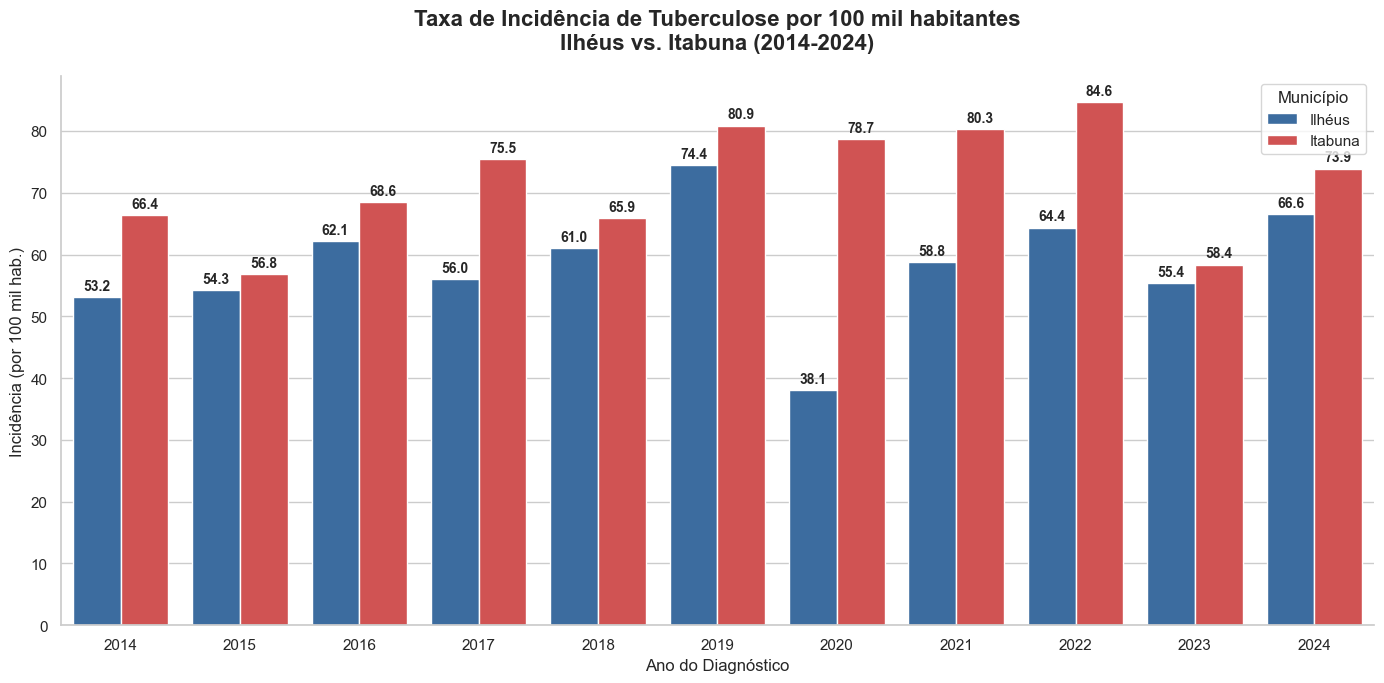

In [7]:
df_inc = df.copy()

if 'Nome_Municipio' not in df_inc.columns:
    df_inc['Nome_Municipio'] = df_inc['Municipio_Residencia'].map(mapa_cidades)

df_inc = df_inc[df_inc['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]
df_inc = df_inc[df_inc['Tipo_Entrada'] == 1.0]

df_inc['Ano'] = df_inc['Data_Diagnostico'].dt.year
df_inc = df_inc[(df_inc['Ano'] >= 2014) & (df_inc['Ano'] <= 2024)]

# 2. AGRUPAMENTO E POPULAÇÃO IBGE
casos_anuais = df_inc.groupby(['Ano', 'Nome_Municipio']).size().reset_index(name='Casos_Novos')

populacao_ibge = {
    'Ilhéus': 178703,
    'Itabuna': 186708
}
casos_anuais['Populacao'] = casos_anuais['Nome_Municipio'].map(populacao_ibge)

# 3. APLICAÇÃO DA FÓRMULA DE INCIDÊNCIA
casos_anuais['Incidencia_100k'] = (casos_anuais['Casos_Novos'] / casos_anuais['Populacao']) * 100000

# 4. PLOTAGEM DO GRÁFICO DE BARRAS AGRUPADAS
fig, ax = plt.subplots(figsize=(14, 7))

# Criando as barras
sns.barplot(data=casos_anuais, 
            x='Ano', 
            y='Incidencia_100k', 
            hue='Nome_Municipio',
            palette=['#2b6cb0', '#e53e3e'], 
            ax=ax)

# Adicionando os valores exatos em cima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10, fontweight='bold')

# Acabamentos visuais
ax.set_title('Taxa de Incidência de Tuberculose por 100 mil habitantes\nIlhéus vs. Itabuna (2014-2024)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
ax.set_ylabel('Incidência (por 100 mil hab.)', fontsize=12)

# Alterando os anos no eixo X para inteiros limpos (removendo as casas decimais)
ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()])

# Organização da legenda
ax.legend(title='Município', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

#### Ao analisarmos os dados normalizados notamos a constância na superioridade em número de casos em Itabuna, mesmo com um número populacional próximo, Ilhéus possui 173 mil habitantes, e Itabuna possui 196 mil, Itabuna liderou em incindência todos os anos.

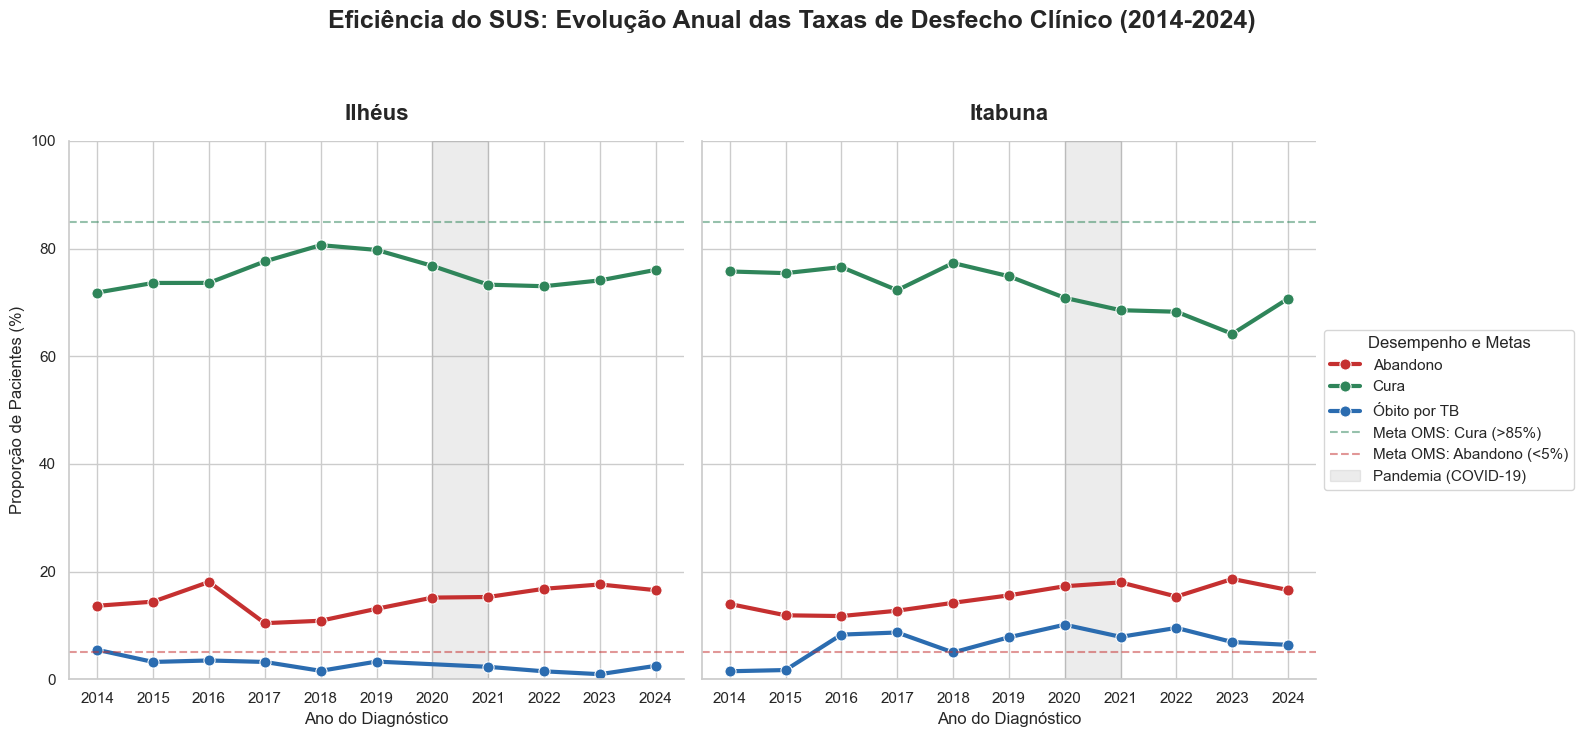

In [10]:
df_desfecho = df.copy()

if 'Nome_Municipio' not in df_desfecho.columns:
    df_desfecho['Nome_Municipio'] = df_desfecho['Municipio_Residencia'].map(mapa_cidades)
df_desfecho = df_desfecho[df_desfecho['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

# Extração do Ano
df_desfecho['Ano'] = df_desfecho['Data_Diagnostico'].dt.year
df_desfecho = df_desfecho[(df_desfecho['Ano'] >= 2014) & (df_desfecho['Ano'] <= 2024)]

# Mapear todos os desfechos importantes do sistema
mapa_encerramentos = {
    1.0: 'Cura',
    2.0: 'Abandono',
    3.0: 'Óbito por TB',
    4.0: 'Óbito por Outras Causas',
    5.0: 'Transferência'
}
df_desfecho['Desfecho_Final'] = df_desfecho['Situacao_Encerramento_Final'].map(mapa_encerramentos)
df_desfecho = df_desfecho.dropna(subset=['Desfecho_Final'])

# 2. CÁLCULO DAS PROPORÇÕES (NORMALIZAÇÃO PELA COORTE)
# Conta os casos por ano, cidade e desfecho
contagem = df_desfecho.groupby(['Ano', 'Nome_Municipio', 'Desfecho_Final']).size().reset_index(name='Casos')

# Conta o total de pacientes encerrados no ano para aquela cidade
totais = df_desfecho.groupby(['Ano', 'Nome_Municipio']).size().reset_index(name='Total_Pacientes')

# Junta as duas tabelas e calcula a porcentagem exata
df_taxas = pd.merge(contagem, totais, on=['Ano', 'Nome_Municipio'])
df_taxas['Taxa (%)'] = (df_taxas['Casos'] / df_taxas['Total_Pacientes']) * 100

# Vamos focar a visualização nos 3 indicadores mais críticos da doença
indicadores_alvo = ['Cura', 'Abandono', 'Óbito por TB']
df_plot = df_taxas[df_taxas['Desfecho_Final'].isin(indicadores_alvo)]

# 3. PLOTAGEM DO GRÁFICO LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
cidades = ['Ilhéus', 'Itabuna']
cores = {'Cura': '#2f855a', 'Abandono': '#c53030', 'Óbito por TB': '#2b6cb0'}

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_cidade = df_plot[df_plot['Nome_Municipio'] == cidade]
    
    # Linhas dos dados reais
    sns.lineplot(data=df_cidade, x='Ano', y='Taxa (%)', hue='Desfecho_Final', 
                 palette=cores, marker='o', markersize=8, linewidth=3, ax=ax)
    
    # Linhas Tracejadas das Metas da OMS
    ax.axhline(85, color='#2f855a', linestyle='--', alpha=0.5, label='Meta OMS: Cura (>85%)')
    ax.axhline(5, color='#c53030', linestyle='--', alpha=0.5, label='Meta OMS: Abandono (<5%)')
    
    # Destaque do período pandêmico
    ax.axvspan(2020, 2021, color='gray', alpha=0.15, label='Pandemia (COVID-19)')
    
    # Acabamentos visuais
    ax.set_title(f'{cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
    ax.set_ylabel('Proporção de Pacientes (%)' if i == 0 else '', fontsize=12)
    ax.set_ylim(0, 100) # Fixa o eixo Y entre 0 e 100% para evitar distorções
    
    anos_unicos = sorted(df_cidade['Ano'].unique())
    ax.set_xticks(anos_unicos)
    ax.set_xticklabels([int(ano) for ano in anos_unicos])
    
    # Organização inteligente da legenda
    if i == 0:
        if ax.get_legend(): ax.legend_.remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles)) # Remove duplicações da legenda (Metas OMS)
        ax.legend(by_label.values(), by_label.keys(), title='Desempenho e Metas', 
                  loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle('Eficiência do SUS: Evolução Anual das Taxas de Desfecho Clínico (2014-2024)', 
             fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()

plt.show()

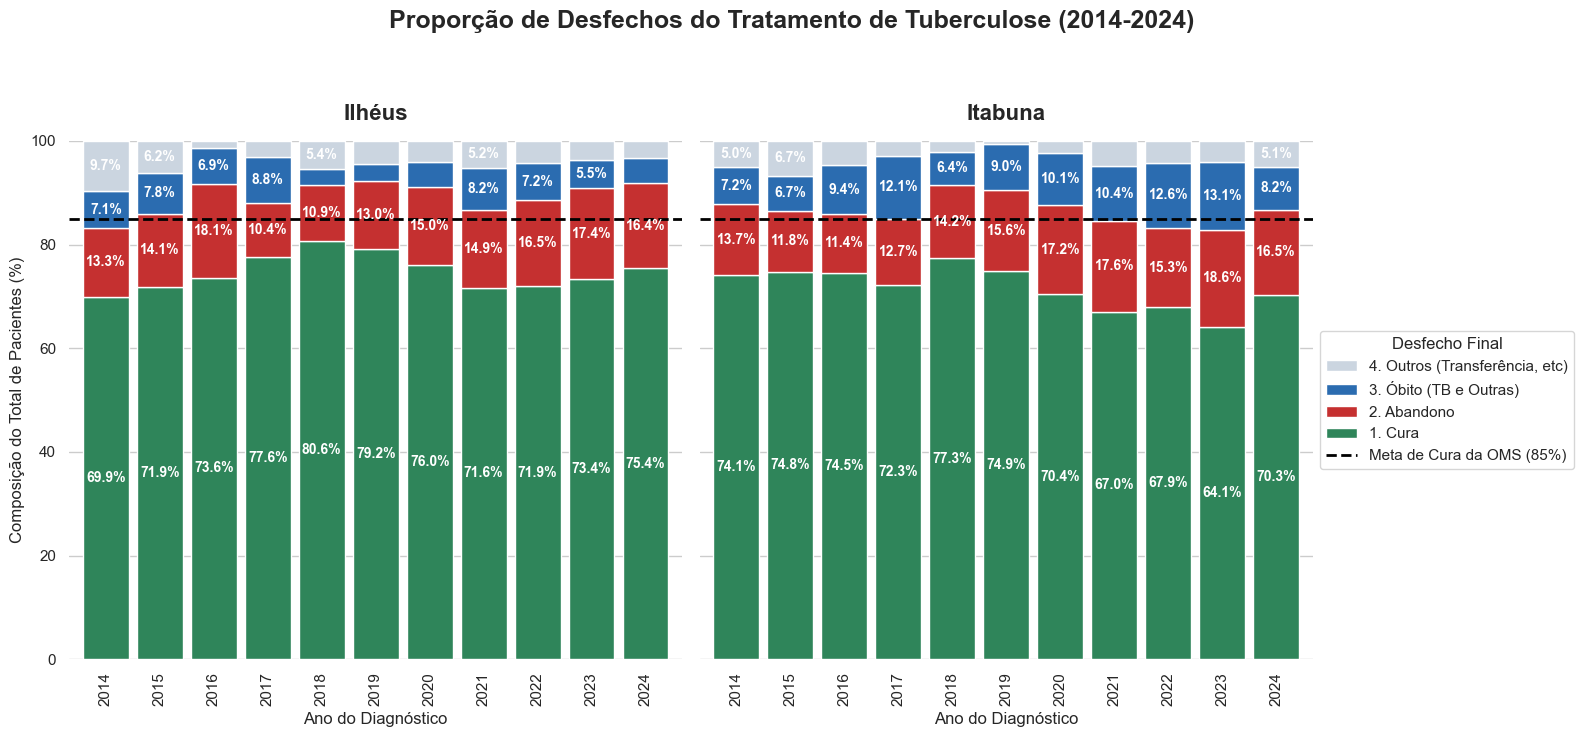

In [11]:
df_stack = df.copy()

if 'Nome_Municipio' not in df_stack.columns:
    df_stack['Nome_Municipio'] = df_stack['Municipio_Residencia'].map(mapa_cidades)
df_stack = df_stack[df_stack['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

df_stack['Ano'] = df_stack['Data_Diagnostico'].dt.year
df_stack = df_stack[(df_stack['Ano'] >= 2014) & (df_stack['Ano'] <= 2024)]

# Agrupamos todos os pacientes para somar 100% exatos
def agrupar_desfecho(val):
    if val == 1.0: return '1. Cura'
    elif val == 2.0: return '2. Abandono'
    elif val in [3.0, 4.0]: return '3. Óbito (TB e Outras)'
    elif pd.notna(val): return '4. Outros (Transferência, etc)'
    return None

df_stack['Desfecho_Grupo'] = df_stack['Situacao_Encerramento_Final'].apply(agrupar_desfecho)
df_stack = df_stack.dropna(subset=['Desfecho_Grupo'])

# 2. PLOTAGEM DO PAINEL LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
cidades = ['Ilhéus', 'Itabuna']
dic_cores = {'1. Cura': '#2f855a', '2. Abandono': '#c53030', '3. Óbito (TB e Outras)': '#2b6cb0', '4. Outros (Transferência, etc)': '#cbd5e0'}

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_cidade = df_stack[df_stack['Nome_Municipio'] == cidade]
    
    # Cria uma tabela cruzada já em formato de porcentagem de 0 a 100
    ct = pd.crosstab(df_cidade['Ano'], df_cidade['Desfecho_Grupo'], normalize='index') * 100
    
    # Garante a ordem correta para a Cura ficar na base da barra
    ordem_cols = sorted(ct.columns)
    ct = ct[ordem_cols]
    cores_plot = [dic_cores[col] for col in ct.columns]
    
    # Plota as barras empilhadas
    ct.plot(kind='bar', stacked=True, color=cores_plot, ax=ax, width=0.85, edgecolor='white')
    
    # Linha da Meta da OMS (Como a Cura está na base, a linha no 85 marca exatamente o alvo)
    ax.axhline(85, color='black', linestyle='--', linewidth=2, label='Meta de Cura da OMS (85%)')
    
    ax.set_title(f'{cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
    ax.set_ylabel('Composição do Total de Pacientes (%)' if i == 0 else '', fontsize=12)
    ax.set_ylim(0, 100)
    
    # Adiciona a porcentagem em texto dentro dos blocos principais (Cura e Abandono)
    for c in ax.containers:
        # Pula as anotações para a linha horizontal
        if type(c) == plt.Line2D: continue
        
        # Formata o texto para aparecer apenas se for um bloco grande o suficiente
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=10, fontweight='bold')

    # Ajustes da Legenda
    if i == 0:
        if ax.get_legend(): ax.legend_.remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        # Inverte a ordem da legenda para combinar com o empilhamento (Cura embaixo)
        ax.legend(reversed(handles), reversed(labels), title='Desfecho Final', 
                  loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle('Proporção de Desfechos do Tratamento de Tuberculose (2014-2024)', fontsize=18, fontweight='bold', y=1.05)
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

#### Para Ilhéus e Itabuna, dos 100% dos pacientes diagnosticados com Tuberculose temos uma variação média de 8%, com os valores estando entre 67% e 80%, com Ilhéus tendo uma média maior que Itabuna, contudo, os números se mantem estáveis mesmo no período de pandemia.

#### A meta de cura de Tuberculose para Organização Mundial da Saúde é de 85%, dessa forma, as cidades analisadas apresentam dados que tornam a Tuberculose ainda o problema de saúde pública à ser combatido, pois ambas estão abaixo da média. Além disso apresentam uma taxa de óbito com média quase tripla em relação a meta de OMS que é de 5%.

/tmp/ipykernel_13838/1770285053.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()], rotation=45)
/tmp/ipykernel_13838/1770285053.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()], rotation=45)


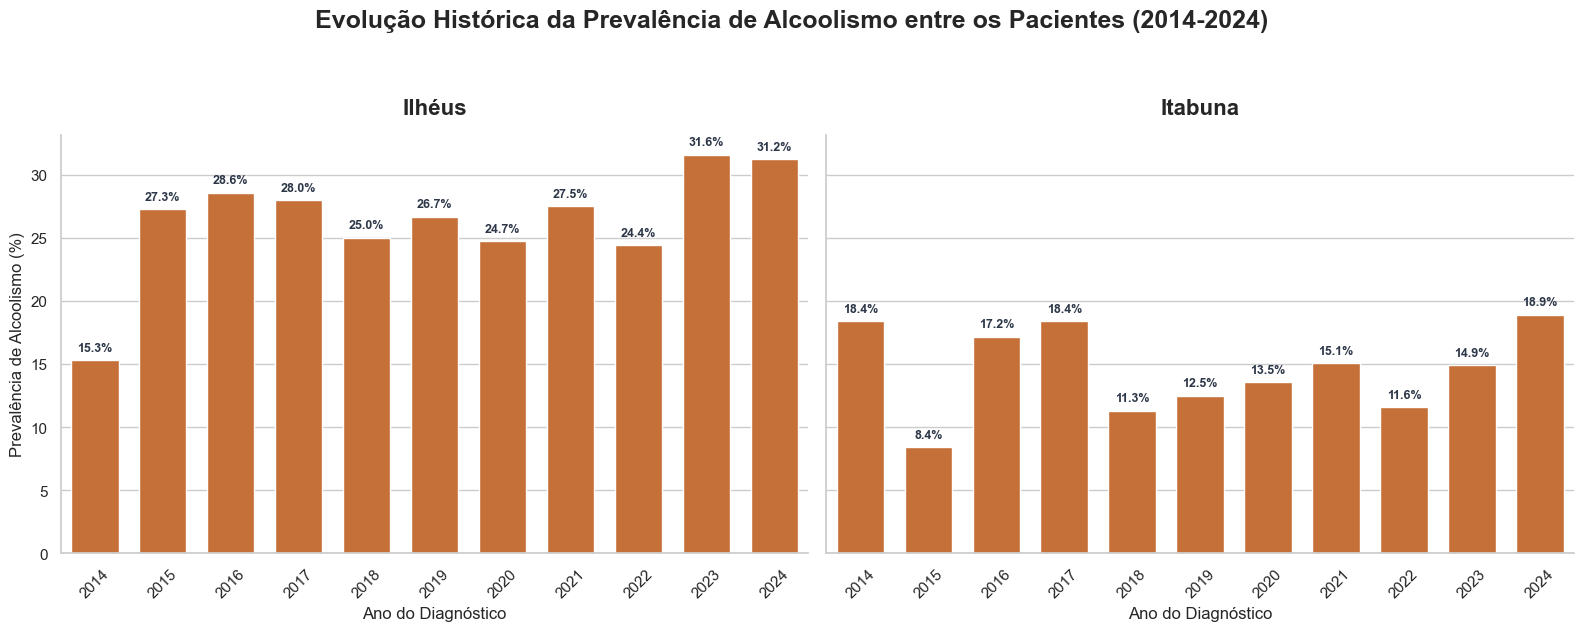

In [13]:
df_alc = df.copy()

if 'Nome_Municipio' not in df_alc.columns:
    df_alc['Nome_Municipio'] = df_alc['Municipio_Residencia'].map(mapa_cidades)
df_alc = df_alc[df_alc['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

df_alc['Ano'] = df_alc['Data_Diagnostico'].dt.year
df_alc = df_alc[(df_alc['Ano'] >= 2014) & (df_alc['Ano'] <= 2024)]
df_alc = df_alc[df_alc['Agravo_Alcoolismo'].isin([1.0, 2.0])]

# Cálculo da proporção anual de alcoolistas por cidade
total_ano = df_alc.groupby(['Ano', 'Nome_Municipio']).size().reset_index(name='Total')
alcoolistas_ano = df_alc[df_alc['Agravo_Alcoolismo'] == 1.0].groupby(['Ano', 'Nome_Municipio']).size().reset_index(name='Alcoolistas')

df_Prevalencia = pd.merge(alcoolistas_ano, total_ano, on=['Ano', 'Nome_Municipio'])
df_Prevalencia['Percentual (%)'] = (df_Prevalencia['Alcoolistas'] / df_Prevalencia['Total']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
cidades = ['Ilhéus', 'Itabuna']

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_plot = df_Prevalencia[df_Prevalencia['Nome_Municipio'] == cidade]
    
    sns.barplot(data=df_plot, x='Ano', y='Percentual (%)', color='#dd6b20', ax=ax, width=0.7)
    
    ax.set_title(f'{cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Ano do Diagnóstico', fontsize=12)
    ax.set_ylabel('Prevalência de Alcoolismo (%)' if i == 0 else '', fontsize=12)
    ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()], rotation=45)
    
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.text(p.get_x() + p.get_width()/2., altura + 0.5, f'{altura:.1f}%', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2d3748')

plt.suptitle('Evolução Histórica da Prevalência de Alcoolismo entre os Pacientes (2014-2024)', fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

#### É notório a grande diferença na relação do Alcoolismo com o agravo da Tuberculose nas cidades de Ilhéus e Itabuna, enquanto Ilhéus se manteve com mais de 25% de seus pacientes de Tuberculose durante todos os anos, tendo pico de 31% nos anos de 2023 e 2024, Itabuna mantem sua média abaixo dos 18%, com seu maior índice sendo 18,4% em 2017.

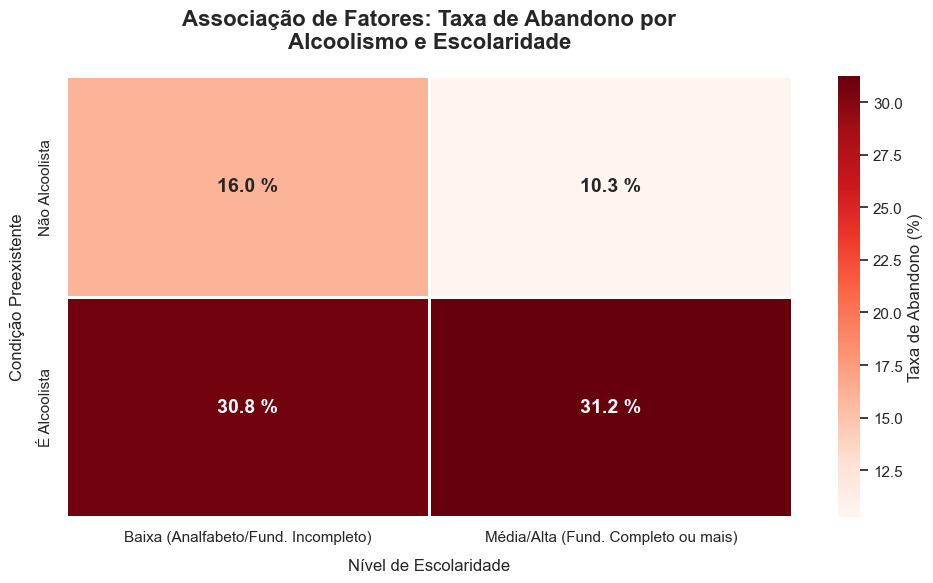

In [6]:
df_assoc = df.copy()

# Focar apenas em quem teve desfecho de Cura (1.0) ou Abandono (2.0)
df_assoc = df_assoc[df_assoc['Situacao_Encerramento_Final'].isin([1.0, 2.0])]

# Criar variável binária para Abandono (1 = Abandono, 0 = Cura)
df_assoc['Abandono_Binario'] = (df_assoc['Situacao_Encerramento_Final'] == 2.0).astype(int)

# Fator 1: Alcoolismo
df_assoc['Alcoolismo'] = df_assoc['Agravo_Alcoolismo'].map({1.0: 'É Alcoolista', 2.0: 'Não Alcoolista'})

# Fator 2: Escolaridade (Simplificada em duas grandes faixas)
def classificar_esc_simples(codigo):
    if codigo in [0.0, 1.0, 2.0, 3.0]: return 'Baixa (Analfabeto/Fund. Incompleto)'
    elif codigo in [4.0, 5.0, 6.0, 7.0, 8.0]: return 'Média/Alta (Fund. Completo ou mais)'
    return None

df_assoc['Nivel_Escolaridade'] = df_assoc['Escolaridade'].apply(classificar_esc_simples)

# Remover quem não tem essas informações
df_assoc = df_assoc.dropna(subset=['Alcoolismo', 'Nivel_Escolaridade'])

# 2. CALCULAR A TAXA DE ABANDONO PARA CADA COMBINAÇÃO
# A média de uma variável 0 e 1 multiplicada por 100 dá exatamente a porcentagem!
tabela_cruzada = df_assoc.pivot_table(
    values='Abandono_Binario', 
    index='Alcoolismo', 
    columns='Nivel_Escolaridade', 
    aggfunc='mean'
) * 100

# 3. PLOTAGEM DO MAPA DE CALOR (HEATMAP)
plt.figure(figsize=(10, 6))

# Usamos o 'Reds' para indicar que quanto mais vermelho, pior (maior abandono)
sns.heatmap(tabela_cruzada, annot=True, fmt='.1f', cmap='Reds', 
            cbar_kws={'label': 'Taxa de Abandono (%)'}, 
            linewidths=1, linecolor='white', annot_kws={"size": 14, "weight": "bold"})

plt.title('Associação de Fatores: Taxa de Abandono por\nAlcoolismo e Escolaridade', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nível de Escolaridade', fontsize=12, labelpad=10)
plt.ylabel('Condição Preexistente', fontsize=12, labelpad=10)

# Adicionando o "símbolo" de porcentagem nos rótulos anotados pelo Seaborn
for t in plt.gca().texts:
    t.set_text(t.get_text() + " %")

plt.tight_layout()
plt.show()

#### Podemos perceber que de forma geral o Alcoolismo é o principal fator para abandono do tratamento de Tuberculose, fazendo a escolaridade tem uma influência baixíssima no no abandono, mas uma influência notável na continuidade do tratamento quando a pessoa não é Alcoolista.

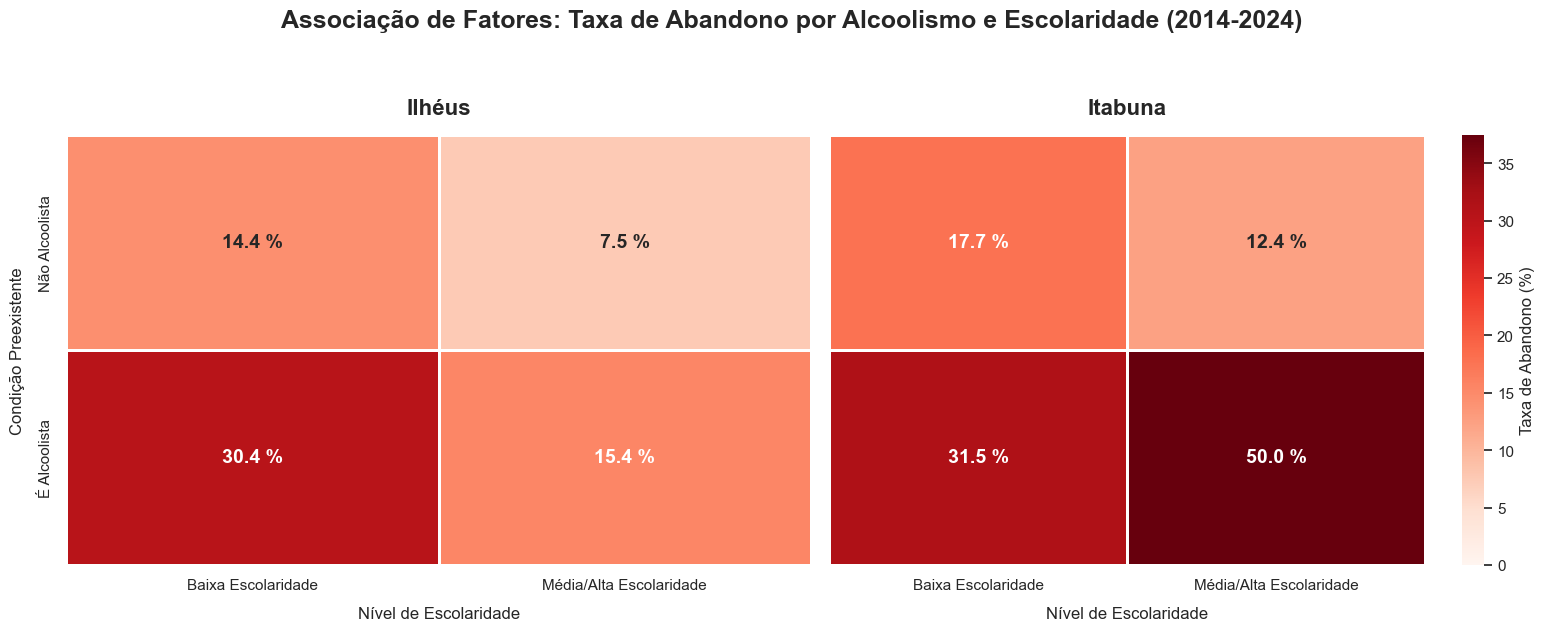

In [7]:
df_assoc = df.copy()

# Garantir o mapeamento das cidades
if 'Nome_Municipio' not in df_assoc.columns:
    df_assoc['Nome_Municipio'] = df_assoc['Municipio_Residencia'].map(mapa_cidades)

df_assoc = df_assoc[df_assoc['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

# Filtros e Variáveis
df_assoc = df_assoc[df_assoc['Situacao_Encerramento_Final'].isin([1.0, 2.0])]
df_assoc['Abandono_Binario'] = (df_assoc['Situacao_Encerramento_Final'] == 2.0).astype(int)
df_assoc['Alcoolismo'] = df_assoc['Agravo_Alcoolismo'].map({1.0: 'É Alcoolista', 2.0: 'Não Alcoolista'})

# Simplificamos os nomes para caberem bem em dois gráficos lado a lado
def classificar_esc_simples(codigo):
    if codigo in [0.0, 1.0, 2.0, 3.0]: return 'Baixa Escolaridade'
    elif codigo in [4.0, 5.0, 6.0, 7.0, 8.0]: return 'Média/Alta Escolaridade'
    return None

df_assoc['Nivel_Escolaridade'] = df_assoc['Escolaridade'].apply(classificar_esc_simples)
df_assoc = df_assoc.dropna(subset=['Alcoolismo', 'Nivel_Escolaridade'])

# 2. DEFINIR ESCALA DE COR GLOBAL (Para comparação justa)
tabela_global = df_assoc.pivot_table(values='Abandono_Binario', index='Alcoolismo', columns='Nivel_Escolaridade', aggfunc='mean') * 100
max_global = tabela_global.max().max() + 5 # Adiciona uma margem de segurança

# 3. PLOTAGEM DO MAPA DE CALOR LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
cidades = ['Ilhéus', 'Itabuna']

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_cidade = df_assoc[df_assoc['Nome_Municipio'] == cidade]
    
    # Calcular a matriz apenas para a cidade atual
    tabela_cruzada = df_cidade.pivot_table(
        values='Abandono_Binario', 
        index='Alcoolismo', 
        columns='Nivel_Escolaridade', 
        aggfunc='mean'
    ) * 100
    
    # Gerar o Heatmap
    sns.heatmap(tabela_cruzada, annot=True, fmt='.1f', cmap='Reds', 
                cbar=True if i == 1 else False, # Mostra a barra de cores apenas no segundo gráfico
                cbar_kws={'label': 'Taxa de Abandono (%)'} if i == 1 else {},
                vmin=0, vmax=max_global, # Força a mesma cor em ambos
                linewidths=1, linecolor='white', annot_kws={"size": 14, "weight": "bold"}, ax=ax)
    
    ax.set_title(f'{cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Nível de Escolaridade', fontsize=12, labelpad=10)
    ax.set_ylabel('Condição Preexistente' if i == 0 else '', fontsize=12, labelpad=10)
    
    # Adicionando o "símbolo" de porcentagem
    for t in ax.texts:
        t.set_text(t.get_text() + " %")

plt.suptitle('Associação de Fatores: Taxa de Abandono por Alcoolismo e Escolaridade (2014-2024)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Ao separarmos os dados por cidade, a dinâmica muda drasticamente. O alcoolismo continua sendo o principal fator de risco, porém, em Itabuna, nota-se uma grave falha na retenção de pacientes com maior grau de instrução: metade (50%) dos pacientes alcoolistas com escolaridade Média/Alta acabam abandonando o tratamento. Em contrapartida, em Ilhéus, a maior escolaridade atua como um claro fator de proteção, ajudando na continuidade do tratamento mesmo entre pacientes alcoolistas.

/tmp/ipykernel_26899/88728360.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


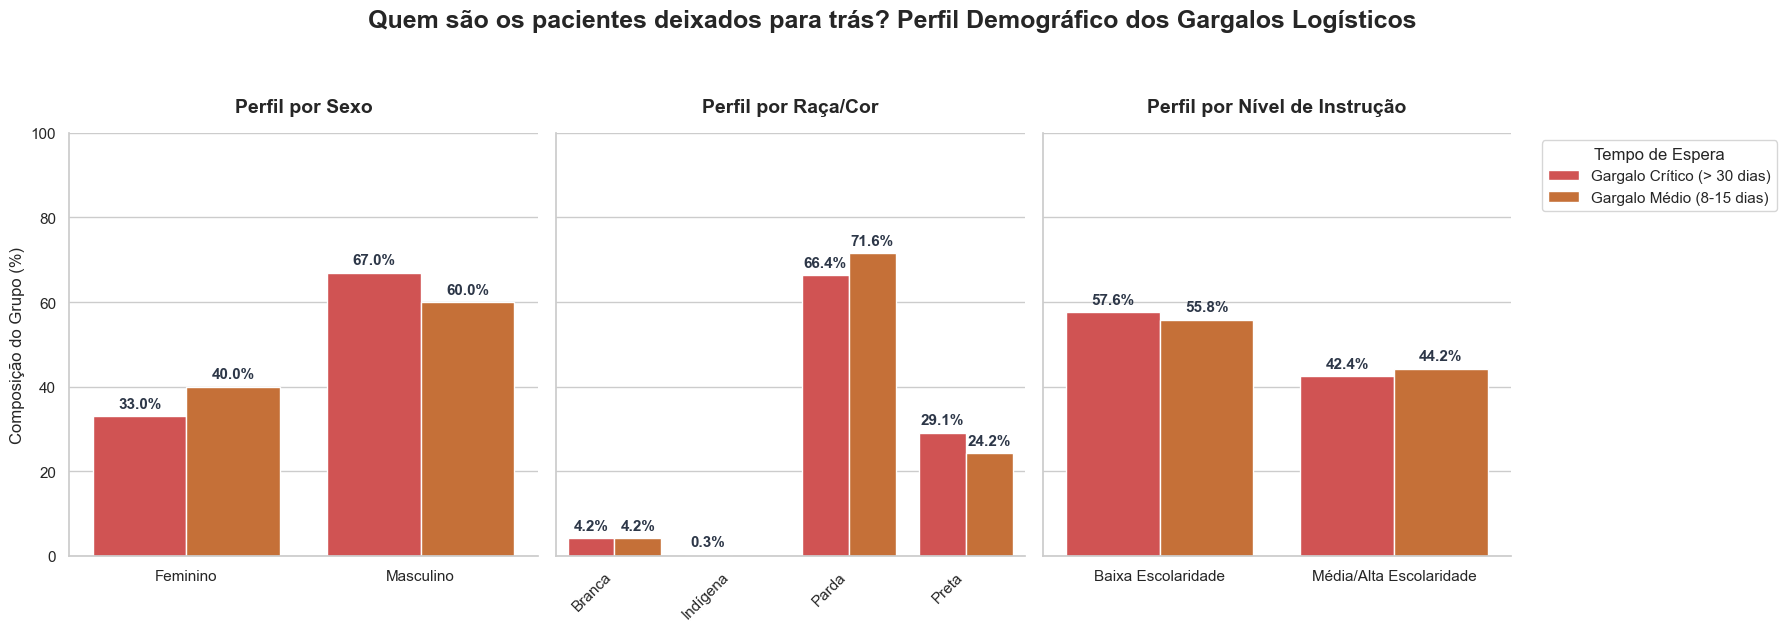

In [9]:
df_perfil = df.copy()

if 'Nome_Municipio' not in df_perfil.columns:
    df_perfil['Nome_Municipio'] = df_perfil['Municipio_Residencia'].map(mapa_cidades)
df_perfil = df_perfil[df_perfil['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

# Recalculando o atraso
df_perfil['Data_Diagnostico'] = pd.to_datetime(df_perfil['Data_Diagnostico'], errors='coerce')
df_perfil['Data_Inicio_Tratamento'] = pd.to_datetime(df_perfil['Data_Inicio_Tratamento'], errors='coerce')
df_perfil['Dias_Atraso'] = (df_perfil['Data_Inicio_Tratamento'] - df_perfil['Data_Diagnostico']).dt.days

# 2. DEFINIÇÃO DOS GRUPOS DE INTERESSE
def definir_grupo_atraso(dias):
    if 8 <= dias <= 15: return 'Gargalo Médio (8-15 dias)'
    elif dias > 30: return 'Gargalo Crítico (> 30 dias)'
    return None # Ignoramos quem foi atendido rápido para focar no problema

df_perfil['Grupo_Atraso'] = df_perfil['Dias_Atraso'].apply(definir_grupo_atraso)
df_alvo = df_perfil.dropna(subset=['Grupo_Atraso']).copy()

# 3. MAPEAMENTO DEMOGRÁFICO
mapa_raca = {1.0: 'Branca', 2.0: 'Preta', 3.0: 'Amarela', 4.0: 'Parda', 5.0: 'Indígena'}
df_alvo['Raça/Cor'] = df_alvo['Raca_Cor'].map(mapa_raca)

def classificar_esc(codigo):
    if codigo in [0.0, 1.0, 2.0, 3.0]: return 'Baixa Escolaridade'
    elif codigo in [4.0, 5.0, 6.0, 7.0, 8.0]: return 'Média/Alta Escolaridade'
    return 'Não Informado'

df_alvo['Escolaridade'] = df_alvo['Escolaridade'].apply(classificar_esc)
df_alvo = df_alvo[(df_alvo['Escolaridade'] != 'Não Informado') & df_alvo['Raça/Cor'].notna()]

# 4. PLOTAGEM DO PAINEL DE PERFIL
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
variaveis = [('Sexo', 'Perfil por Sexo'), 
             ('Raça/Cor', 'Perfil por Raça/Cor'), 
             ('Escolaridade', 'Perfil por Nível de Instrução')]

cores = {'Gargalo Médio (8-15 dias)': '#dd6b20', 'Gargalo Crítico (> 30 dias)': '#e53e3e'}

for i, (var, titulo) in enumerate(variaveis):
    ax = axes[i]
    
    # Calcula a porcentagem dentro de cada grupo de atraso
    ct = pd.crosstab(df_alvo[var], df_alvo['Grupo_Atraso'], normalize='columns') * 100
    ct_melted = ct.reset_index().melt(id_vars=var, var_name='Tempo de Espera', value_name='Porcentagem (%)')
    
    sns.barplot(data=ct_melted, x=var, y='Porcentagem (%)', hue='Tempo de Espera', 
                palette=cores, ax=ax)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Composição do Grupo (%)' if i == 0 else '')
    ax.set_ylim(0, 100)
    
    # Formatação dos rótulos do Eixo X para não encavalarem
    if var == 'Raça/Cor':
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
    # Adicionando os valores nas barras
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.text(p.get_x() + p.get_width()/2, altura + 2, 
                    f'{altura:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#2d3748')
            
    # Limpando as legendas duplicadas
    if i < 2:
        if ax.get_legend(): ax.get_legend().remove()
    else:
        ax.legend(title='Tempo de Espera', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Quem são os pacientes deixados para trás? Perfil Demográfico dos Gargalos Logísticos', 
             fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

#### O gargálo do início do tratamento de Tuberculose de Ilhéus e Itabuna afeta majoritariamente homens, pardos e com baixa escolaridade.

/tmp/ipykernel_26899/3562658106.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_26899/3562658106.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


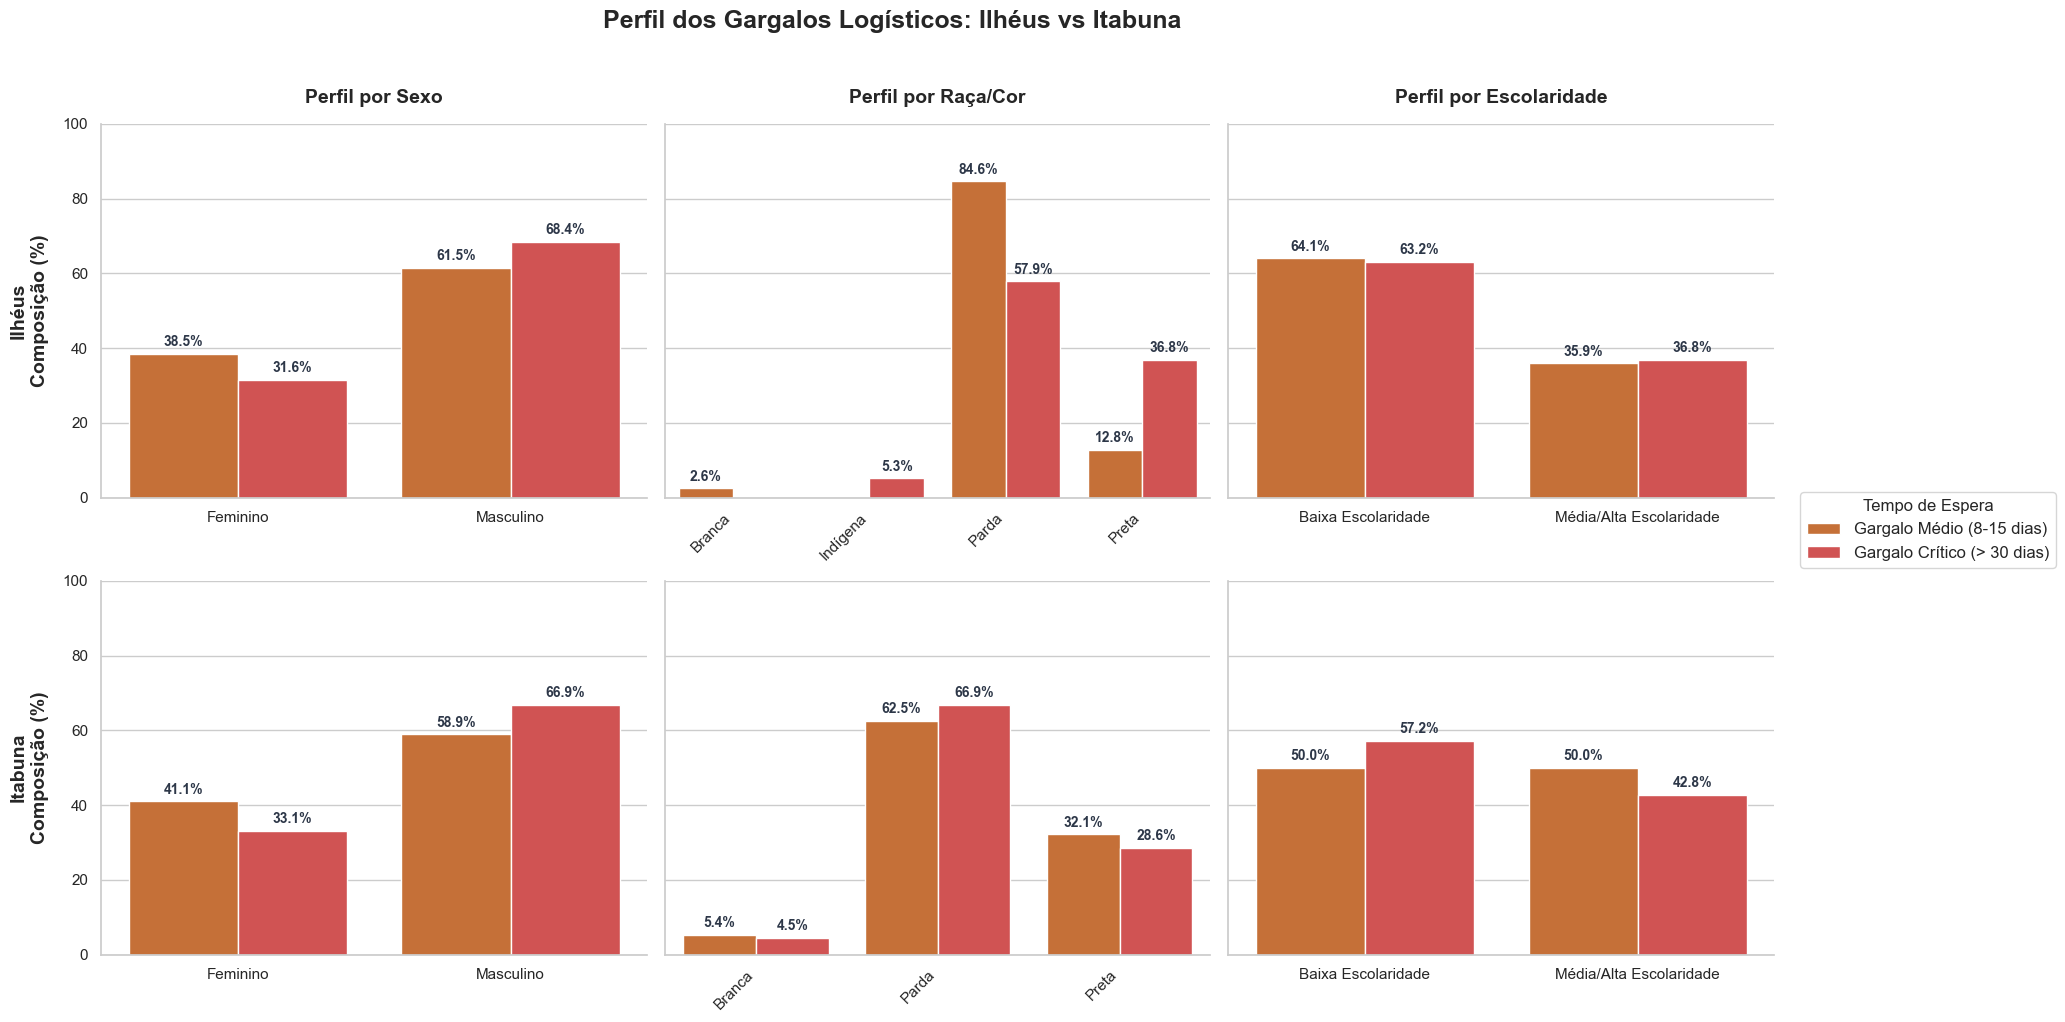

In [10]:
df_perfil = df.copy()

if 'Nome_Municipio' not in df_perfil.columns:
    df_perfil['Nome_Municipio'] = df_perfil['Municipio_Residencia'].map(mapa_cidades)
df_perfil = df_perfil[df_perfil['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

# Cálculos de tempo
df_perfil['Data_Diagnostico'] = pd.to_datetime(df_perfil['Data_Diagnostico'], errors='coerce')
df_perfil['Data_Inicio_Tratamento'] = pd.to_datetime(df_perfil['Data_Inicio_Tratamento'], errors='coerce')
df_perfil['Dias_Atraso'] = (df_perfil['Data_Inicio_Tratamento'] - df_perfil['Data_Diagnostico']).dt.days

# Agrupamentos
def definir_grupo_atraso(dias):
    if 8 <= dias <= 15: return 'Gargalo Médio (8-15 dias)'
    elif dias > 30: return 'Gargalo Crítico (> 30 dias)'
    return None

df_perfil['Grupo_Atraso'] = df_perfil['Dias_Atraso'].apply(definir_grupo_atraso)
df_alvo = df_perfil.dropna(subset=['Grupo_Atraso']).copy()

# Mapeamentos Demográficos
mapa_raca = {1.0: 'Branca', 2.0: 'Preta', 3.0: 'Amarela', 4.0: 'Parda', 5.0: 'Indígena'}
df_alvo['Raça/Cor'] = df_alvo['Raca_Cor'].map(mapa_raca)

def classificar_esc(codigo):
    if codigo in [0.0, 1.0, 2.0, 3.0]: return 'Baixa Escolaridade'
    elif codigo in [4.0, 5.0, 6.0, 7.0, 8.0]: return 'Média/Alta Escolaridade'
    return 'Não Informado'

df_alvo['Escolaridade'] = df_alvo['Escolaridade'].apply(classificar_esc)
df_alvo = df_alvo[(df_alvo['Escolaridade'] != 'Não Informado') & df_alvo['Raça/Cor'].notna()]

# 2. PLOTAGEM DO PAINEL MATRICIAL (2 Cidades x 3 Variáveis)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
cidades = ['Ilhéus', 'Itabuna']
variaveis = [('Sexo', 'Perfil por Sexo'), 
             ('Raça/Cor', 'Perfil por Raça/Cor'), 
             ('Escolaridade', 'Perfil por Escolaridade')]

cores = {'Gargalo Médio (8-15 dias)': '#dd6b20', 'Gargalo Crítico (> 30 dias)': '#e53e3e'}

for row, cidade in enumerate(cidades):
    df_cidade = df_alvo[df_alvo['Nome_Municipio'] == cidade]
    
    for col, (var, titulo) in enumerate(variaveis):
        ax = axes[row, col]
        
        # Só tenta plotar se houver dados
        if not df_cidade.empty:
            ct = pd.crosstab(df_cidade[var], df_cidade['Grupo_Atraso'], normalize='columns') * 100
            
            # Garantindo que ambas as colunas de atraso existam na tabela, mesmo se forem zeradas
            for grupo in cores.keys():
                if grupo not in ct.columns:
                    ct[grupo] = 0.0
                    
            ct_melted = ct.reset_index().melt(id_vars=var, var_name='Tempo de Espera', value_name='Porcentagem (%)')
            
            sns.barplot(data=ct_melted, x=var, y='Porcentagem (%)', hue='Tempo de Espera', 
                        palette=cores, ax=ax, hue_order=cores.keys())
            
            # Anotações nas barras
            for p in ax.patches:
                altura = p.get_height()
                if altura > 0:
                    ax.text(p.get_x() + p.get_width()/2, altura + 2, 
                            f'{altura:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#2d3748')
        
        # Formatação Visual
        if row == 0:
            ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
            
        if col == 0:
            ax.set_ylabel(f'{cidade}\nComposição (%)', fontsize=14, fontweight='bold', labelpad=10)
        else:
            ax.set_ylabel('')
            
        ax.set_xlabel('')
        ax.set_ylim(0, 100)
        
        if var == 'Raça/Cor':
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            
        # Limpa todas as legendas individuais
        if ax.get_legend() is not None:
            ax.get_legend().remove()

# Legenda global única
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Tempo de Espera', bbox_to_anchor=(1.0, 0.5), loc='center left', fontsize=12)

plt.suptitle('Perfil dos Gargalos Logísticos: Ilhéus vs Itabuna', fontsize=18, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

#### O perfil é o mesmo em ambas as cidades, porém o fator escolaridade tem uma influência maior em Ilhéus.

/tmp/ipykernel_26899/2501095211.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, y='Perfil_Paciente', x='Taxa_Abandono',
/tmp/ipykernel_26899/2501095211.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, y='Perfil_Paciente', x='Taxa_Abandono',


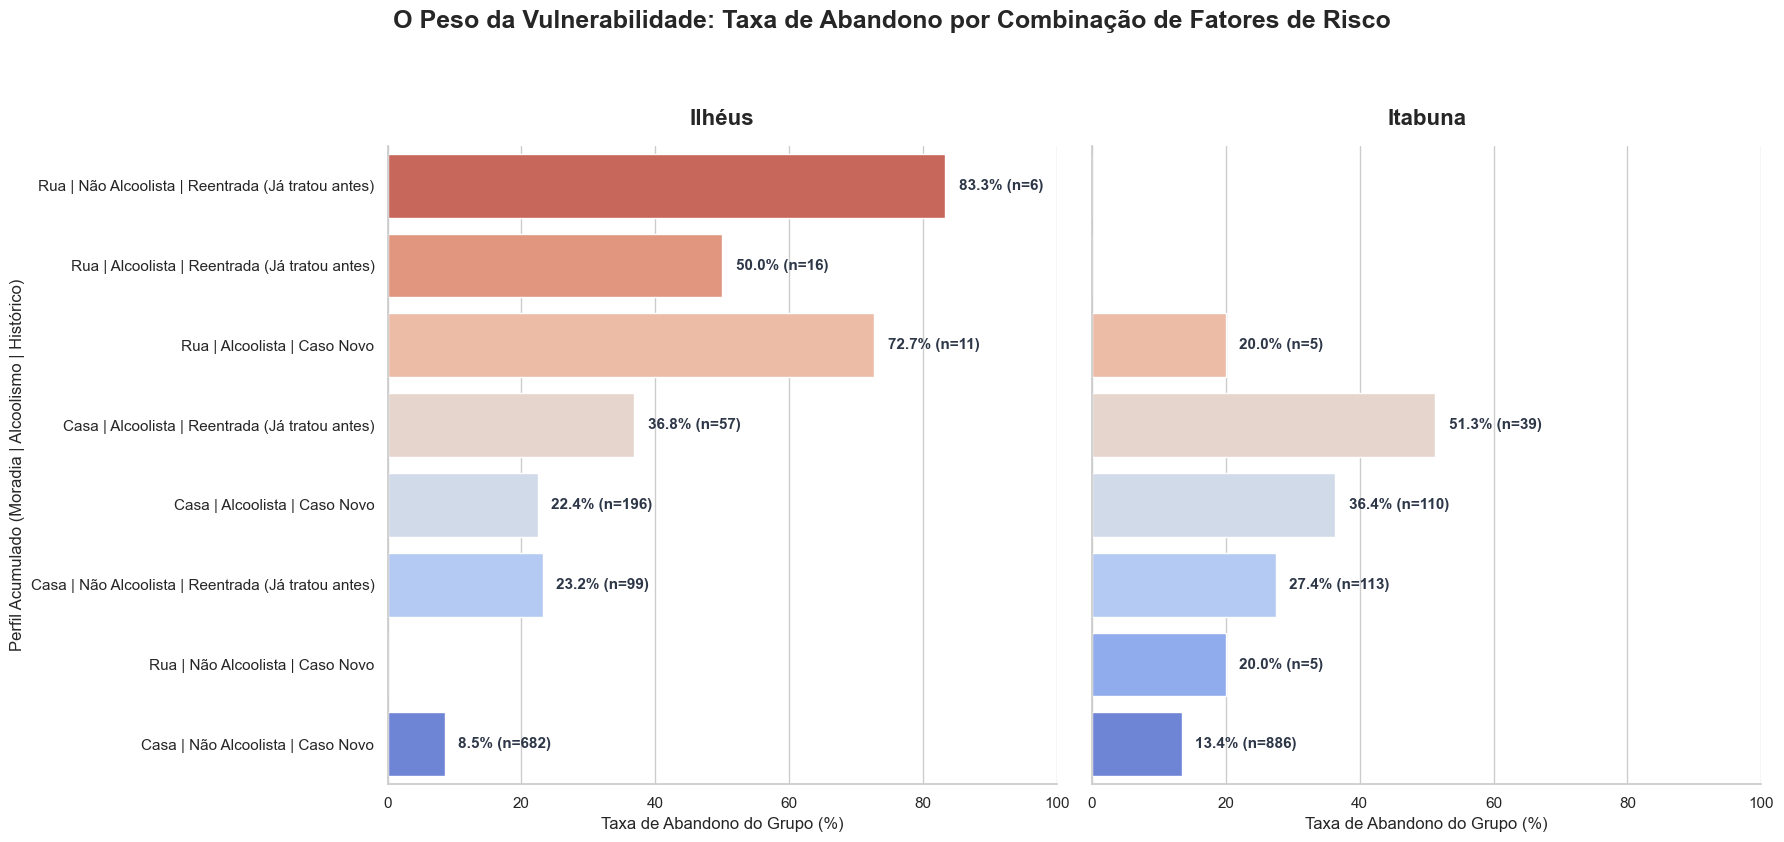

In [12]:
df_multi = df.copy()

if 'Nome_Municipio' not in df_multi.columns:
    df_multi['Nome_Municipio'] = df_multi['Municipio_Residencia'].map(mapa_cidades)
df_multi = df_multi[df_multi['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

# Filtro apenas para quem teve desfecho conclusivo (Cura ou Abandono)
df_multi = df_multi[df_multi['Situacao_Encerramento_Final'].isin([1.0, 2.0])]
df_multi['Abandono_Binario'] = (df_multi['Situacao_Encerramento_Final'] == 2.0).astype(int) * 100

# Mapeamento dos 3 Fatores de Risco
df_multi['Moradia'] = df_multi['Populacao_Situacao_Rua'].map({1.0: 'Rua', 2.0: 'Casa'})
df_multi['Alcoolismo'] = df_multi['Agravo_Alcoolismo'].map({1.0: 'Alcoolista', 2.0: 'Não Alcoolista'})

# Para o Histórico, agrupamos Recidiva(2.0) e Reingresso(3.0) como "Reentrada"
def classificar_entrada(codigo):
    if codigo == 1.0: return 'Caso Novo'
    elif codigo in [2.0, 3.0]: return 'Reentrada (Já tratou antes)'
    return None

df_multi['Historico'] = df_multi['Tipo_Entrada'].apply(classificar_entrada)

# Remover registros com dados faltantes nestas colunas
df_multi = df_multi.dropna(subset=['Moradia', 'Alcoolismo', 'Historico'])

# Criar a "Assinatura" do Paciente combinando os 3 fatores
df_multi['Perfil_Paciente'] = df_multi['Moradia'] + " | " + df_multi['Alcoolismo'] + " | " + df_multi['Historico']

# 2. CÁLCULO DAS TAXAS E FILTRO DE CONFIABILIDADE
dados_perfil = df_multi.groupby(['Nome_Municipio', 'Perfil_Paciente']).agg(
    Taxa_Abandono=('Abandono_Binario', 'mean'),
    Total_Pacientes=('Abandono_Binario', 'count')
).reset_index()

# FILTRO ESTATÍSTICO: Excluir perfis muito raros (menos de 5 pacientes em 10 anos) 
# Isso evita distorções (ex: 1 paciente no perfil que abandonou gerando 100% no gráfico)
dados_perfil = dados_perfil[dados_perfil['Total_Pacientes'] >= 5]

# Ordenar do pior cenário para o melhor globalmente para padronizar o eixo Y
ordem_perfis = dados_perfil.groupby('Perfil_Paciente')['Taxa_Abandono'].mean().sort_values(ascending=False).index

# 3. PLOTAGEM DO RANKING LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
cidades = ['Ilhéus', 'Itabuna']

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_plot = dados_perfil[dados_perfil['Nome_Municipio'] == cidade].set_index('Perfil_Paciente')
    
    # Reindexar para garantir a mesma ordem em ambos os gráficos, preenchendo vazios com 0
    df_plot = df_plot.reindex(ordem_perfis).fillna(0).reset_index()
    
    # Criar paleta de cores gradiente (Vermelho para alto risco, Azul para baixo risco)
    sns.barplot(data=df_plot, y='Perfil_Paciente', x='Taxa_Abandono', 
                palette='coolwarm_r', ax=ax)
    
    ax.set_title(f'{cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Taxa de Abandono do Grupo (%)', fontsize=12)
    ax.set_ylabel('Perfil Acumulado (Moradia | Alcoolismo | Histórico)' if i == 0 else '', fontsize=12)
    ax.set_xlim(0, 100)
    
    # Adicionando a porcentagem e o "n" amostral dentro da barra
    for index, row in df_plot.iterrows():
        taxa = row['Taxa_Abandono']
        total = int(row['Total_Pacientes'])
        if total > 0: # Só anota se o grupo existir naquela cidade
            ax.text(taxa + 2, index, f'{taxa:.1f}% (n={total})', 
                    va='center', fontsize=11, fontweight='bold', color='#2d3748')

plt.suptitle('O Peso da Vulnerabilidade: Taxa de Abandono por Combinação de Fatores de Risco', fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_26899/1988624874.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, y='Perfil_Paciente', x='Taxa_Abandono',
/tmp/ipykernel_26899/1988624874.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, y='Perfil_Paciente', x='Taxa_Abandono',


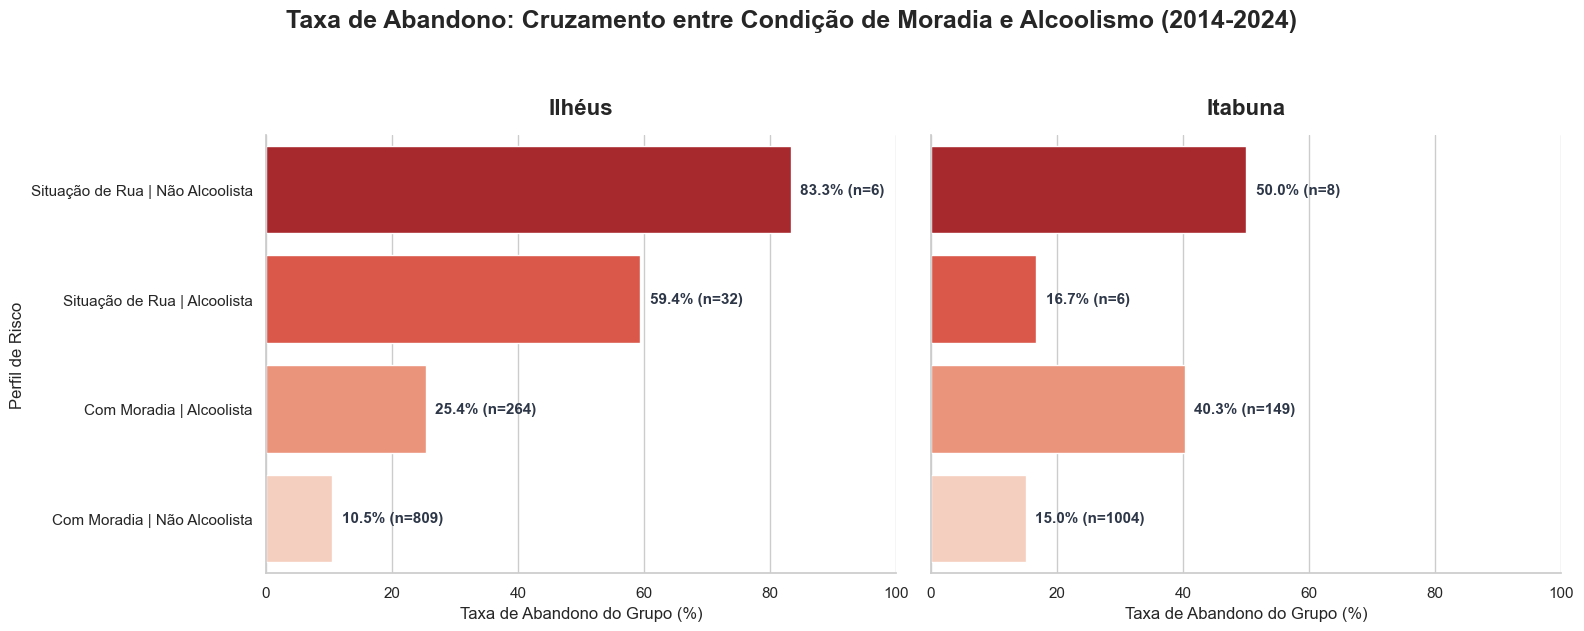

In [13]:
df_multi = df.copy()

if 'Nome_Municipio' not in df_multi.columns:
    df_multi['Nome_Municipio'] = df_multi['Municipio_Residencia'].map(mapa_cidades)
df_multi = df_multi[df_multi['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

# Filtro apenas para quem teve desfecho conclusivo (Cura ou Abandono)
df_multi = df_multi[df_multi['Situacao_Encerramento_Final'].isin([1.0, 2.0])]
df_multi['Abandono_Binario'] = (df_multi['Situacao_Encerramento_Final'] == 2.0).astype(int) * 100

# Mapeamento dos 2 Fatores de Risco principais
df_multi['Moradia'] = df_multi['Populacao_Situacao_Rua'].map({1.0: 'Situação de Rua', 2.0: 'Com Moradia'})
df_multi['Alcoolismo'] = df_multi['Agravo_Alcoolismo'].map({1.0: 'Alcoolista', 2.0: 'Não Alcoolista'})

# Remover registros com dados faltantes nestas colunas
df_multi = df_multi.dropna(subset=['Moradia', 'Alcoolismo'])

# Criar a "Assinatura" do Paciente combinando os 2 fatores
df_multi['Perfil_Paciente'] = df_multi['Moradia'] + " | " + df_multi['Alcoolismo']

# 2. CÁLCULO DAS TAXAS E ORDENAÇÃO
dados_perfil = df_multi.groupby(['Nome_Municipio', 'Perfil_Paciente']).agg(
    Taxa_Abandono=('Abandono_Binario', 'mean'),
    Total_Pacientes=('Abandono_Binario', 'count')
).reset_index()

# Ordenar do pior cenário para o melhor globalmente para padronizar o eixo Y
ordem_perfis = dados_perfil.groupby('Perfil_Paciente')['Taxa_Abandono'].mean().sort_values(ascending=False).index

# 3. PLOTAGEM DO RANKING LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
cidades = ['Ilhéus', 'Itabuna']

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_plot = dados_perfil[dados_perfil['Nome_Municipio'] == cidade].set_index('Perfil_Paciente')
    
    # Reindexar para garantir a mesma ordem em ambos os gráficos
    df_plot = df_plot.reindex(ordem_perfis).fillna(0).reset_index()
    
    # Criar paleta de cores gradiente focada no vermelho
    sns.barplot(data=df_plot, y='Perfil_Paciente', x='Taxa_Abandono', 
                palette='Reds_r', ax=ax)
    
    ax.set_title(f'{cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Taxa de Abandono do Grupo (%)', fontsize=12)
    ax.set_ylabel('Perfil de Risco' if i == 0 else '', fontsize=12)
    ax.set_xlim(0, 100)
    
    # Adicionando a porcentagem e o "n" amostral dentro ou logo após a barra
    for index, row in df_plot.iterrows():
        taxa = row['Taxa_Abandono']
        total = int(row['Total_Pacientes'])
        if total > 0: 
            ax.text(taxa + 1.5, index, f'{taxa:.1f}% (n={total})', 
                    va='center', fontsize=11, fontweight='bold', color='#2d3748')

plt.suptitle('Taxa de Abandono: Cruzamento entre Condição de Moradia e Alcoolismo (2014-2024)', fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

#### Novamente chegamos a conclusão que a vulnerabilidade social é o principal fator para abandono do tratamento de tuberculose.

In [15]:
# Busca qualquer coluna que tenha "Sintoma", "Data" ou "DT" no nome
colunas_suspeitas = [col for col in df.columns if 'sintoma' in col.lower() or 'dt' in col.lower() or 'data' in col.lower()]

print("Colunas encontradas:")
for col in colunas_suspeitas:
    print(f"- {col}")

Colunas encontradas:
- Data_Notificacao
- Data_Diagnostico
- Data_Digitacao_Sistema
- Data_Inicio_Tratamento
- Data_Atualizacao_Notificacao
- Data_Mudanca_Esquema
- Data_Encerramento
